In [24]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [25]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


In [26]:
def plot_patron(x_principal, y_principal, x_segundario, y_segundario, titulo,
                mins_principal, maxs_principal, mins_seg=None, maxs_seg=None,
                dx_error_principal=None, dx_error_segundario=None, dy_error=0.01):
    
    color_principal = "#51D63F" 
    color_segundario = "#D6259B"  
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(titulo, fontsize=20, fontweight='bold')
    ax.set_xlabel('Theta (rad)',fontsize=20,fontweight='bold')
    ax.set_ylabel('Intensidad (mV)', fontsize=20,fontweight= 'bold')
    ax.tick_params(axis="both", labelsize=15)
    
    ax.grid(True, alpha=0.5)
    
    # === GRAFICA PRINCIPAL ===
    ax.errorbar(
        x_principal, y_principal,
        xerr=dx_error_principal, yerr=dy_error,
        fmt='-', color=color_principal, ecolor='black', elinewidth=0.8, capsize=2,
        label='Doble rendija'
    )
    
    # === MINI-GRAFICA ===
    ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right', borderpad=2)
    
    ax_inset.errorbar(
        x_segundario, y_segundario,
        xerr=dx_error_segundario, yerr=dy_error,
        fmt='-', color=color_segundario, ecolor='black', elinewidth=0.8, capsize=2
    )
        
    ax_inset.set_title('Rendija sencilla', fontsize=10, fontweight='bold')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, alpha=0.5)

    # === Leyenda final ===
    ax.legend(loc='upper left', fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()


Rango de theta_doble: -0.0125 a 0.0114 rad
Rango de theta_simple: -0.0090 a 0.0295 rad


C:\Users\Flutt\AppData\Local\Temp\ipykernel_58672\326858759.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


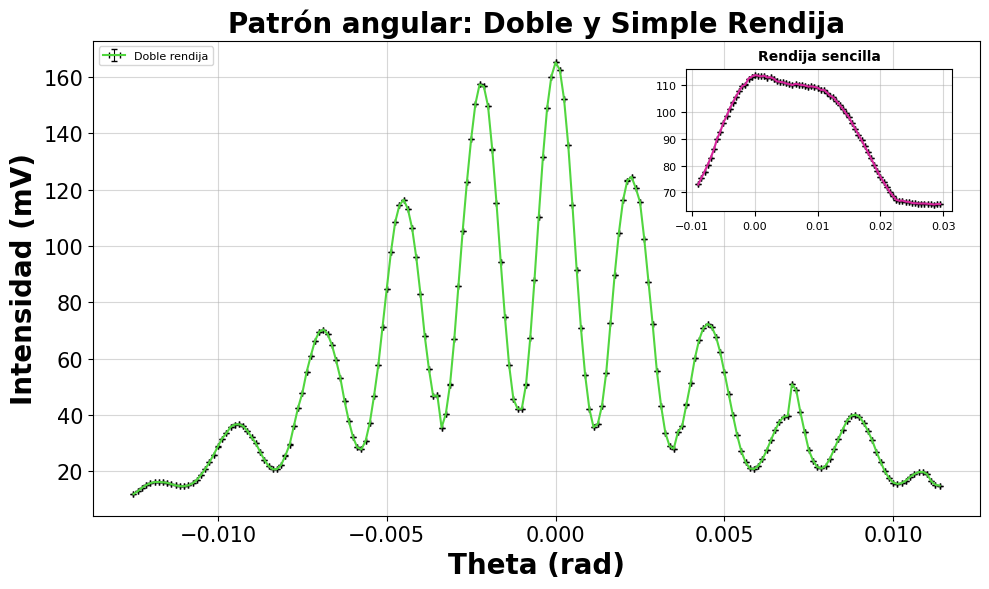

In [27]:
# --- Cargar datos ---
ondulatorio_doble = leer_columnas("Ondulatorio_Doble_Rendija.txt")
ondulatorio_simple = leer_columnas("Ondulatorio_Rendija_Sencilla.txt")

x_doble, y_doble = ondulatorio_doble[0]*10e-4, ondulatorio_doble[1]
x_simple, y_simple = ondulatorio_simple[0]*10e-4, ondulatorio_simple[1]

# --- Parámetro geométrico ---
L = 40.0  # cm (distancia rendija-pantalla)

# --- Máximos globales ---
idx_max_doble = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

# --- Centros en el máximo ---
x_central_doble = x_doble[idx_max_doble]
x_central_simple = x_simple[idx_max_simple]

# --- CORRECCIÓN: Conversión a ángulo para óptica ---
# Para ángulos pequeños en óptica: θ ≈ (x - x_central) / L
theta_doble = (x_doble - x_central_doble) / L
theta_simple = (x_simple - x_central_simple) / L

# --- Mínimos ---
idx_min_doble = np.argmin(y_doble)
idx_min_simple = np.argmin(y_simple)

# --- Puntos en coordenadas angulares ---
mins_principal = [(theta_doble[idx_min_doble], y_doble[idx_min_doble])]
maxs_principal = [(0.0, y_doble[idx_max_doble])]

mins_seg = [(theta_simple[idx_min_simple], y_simple[idx_min_simple])]
maxs_seg = [(0.0, y_simple[idx_max_simple])]

# --- Incertidumbres ---
dx_error_micrometro = 0.0005  ; dy_error = 0.01   #cm , mV

dtheta_doble = dx_error_micrometro *10e-4 / L
dtheta_simple = dx_error_micrometro *10e-4 / L

print(f"Rango de theta_doble: {theta_doble.min():.4f} a {theta_doble.max():.4f} rad")
print(f"Rango de theta_simple: {theta_simple.min():.4f} a {theta_simple.max():.4f} rad")

# --- Llamar a la función de ploteo ---
plot_patron(theta_doble, y_doble,
            theta_simple, y_simple,
            "Patrón angular: Doble y Simple Rendija",
            mins_principal, maxs_principal,
            mins_seg, maxs_seg,
            dx_error_principal=dtheta_doble,
            dx_error_segundario=dtheta_simple,
            dy_error=dy_error)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- MODELO FRAUNHOFER (campo lejano) ---
def modelo_fraunhofer(theta, I0, a, d, lambda_eff, fondo):
    """
    Modelo Fraunhofer para doble rendija:
    I = I0 * [sin(β)/β]^2 * cos²(δ) + fondo
    donde:
    β = (π * a * sinθ) / λ
    δ = (π * d * sinθ) / λ
    """
    beta = (np.pi * a * np.sin(theta)) / lambda_eff
    delta = (np.pi * d * np.sin(theta)) / lambda_eff
    
    # Término de difracción
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc_term = np.where(np.abs(beta) < 1e-10, 1.0, np.sin(beta) / beta)
    difraccion = sinc_term ** 2
    
    # Término de interferencia
    interferencia = np.cos(delta) ** 2
    
    return I0 * difraccion * interferencia + fondo

# --- MODELO FRESNEL (campo cercano) ---
def modelo_fresnel(theta, I0, a, d, lambda_eff, fondo, L):
    """
    Modelo Fresnel para doble rendija:
    Para ángulos pequeños: sinθ ≈ θ ≈ x/L
    I = I0 * [sin(β)/β]^2 * cos²(δ) + fondo
    donde:
    β = (π * a * θ) / λ
    δ = (π * d * θ) / λ
    """
    beta = (np.pi * a * theta) / lambda_eff
    delta = (np.pi * d * theta) / lambda_eff
    
    # Término de difracción
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc_term = np.where(np.abs(beta) < 1e-10, 1.0, np.sin(beta) / beta)
    difraccion = sinc_term ** 2
    
    # Término de interferencia
    interferencia = np.cos(delta) ** 2
    
    return I0 * difraccion * interferencia + fondo

# --- FUNCIÓN DE AJUSTE MEJORADA ---
def ajustar_patron_doble_rendija(theta, y, L, modelo='fresnel'):
    """
    Ajusta el patrón experimental a los modelos teóricos
    """
    print(f"=== AJUSTE CON MODELO {modelo.upper()} ===")
    
    # Parámetros iniciales basados en valores conocidos
    I0_guess = 165.0  # mV (máximo observado)
    fondo_guess = 11.0  # mV (mínimo observado)
    a_guess = 0.01  # cm (0.1 mm)
    d_guess = 0.0356  # cm (0.356 mm)
    lambda_guess = 6.7e-5  # cm (632.8 nm)
    
    print("Parámetros iniciales:")
    print(f"  I0: {I0_guess} mV")
    print(f"  Fondo: {fondo_guess} mV")
    print(f"  a: {a_guess} cm")
    print(f"  d: {d_guess} cm")
    print(f"  λ: {lambda_guess*1e5:.1f} nm")
    
    if modelo == 'fraunhofer':
        p0 = [I0_guess, a_guess, d_guess, lambda_guess, fondo_guess]
        bounds = ([100, 0.01, 0.02, 5e-5, 5],
                  [200, 0.01, 0.05, 8e-5, 20])
        popt, pcov = curve_fit(modelo_fraunhofer, theta, y, p0=p0, bounds=bounds, maxfev=10000)
    else:  # fresnel
        p0 = [I0_guess, a_guess, d_guess, lambda_guess, fondo_guess, L]
        bounds = ([100, 0.01, 0.02, 5e-5, 5, L*0.9],
                  [200, 0.01, 0.05, 8e-5, 20, L*1.1])
        popt, pcov = curve_fit(modelo_fresnel, theta, y, p0=p0, bounds=bounds, maxfev=10000)
    
    return popt, pcov

# --- GRÁFICA COMPARATIVA CON AJUSTE ---
def plot_patron_con_ajuste(theta_principal, y_principal, theta_segundario, y_segundario, 
                          titulo, popt_fraunhofer, popt_fresnel, L):
    
    color_principal = "#51D63F" 
    color_segundario = "#D6259B"
    color_fraunhofer = "#FF5733"
    color_fresnel = "#3498DB"
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfica superior: Datos y ajustes
    ax1.plot(theta_principal, y_principal, 'o-', color=color_principal, 
             markersize=3, linewidth=0.5, alpha=0.7, label='Datos experimentales')
    
    # Curvas de ajuste
    theta_fit = np.linspace(theta_principal.min(), theta_principal.max(), 1000)
    
    if popt_fraunhofer is not None:
        y_fraunhofer = modelo_fraunhofer(theta_fit, *popt_fraunhofer)
        ax1.plot(theta_fit, y_fraunhofer, '-', color=color_fraunhofer, 
                linewidth=2, label='Ajuste Fraunhofer', alpha=0.8)
    
    if popt_fresnel is not None:
        y_fresnel = modelo_fresnel(theta_fit, *popt_fresnel)
        ax1.plot(theta_fit, y_fresnel, '--', color=color_fresnel, 
                linewidth=2, label='Ajuste Fresnel', alpha=0.8)
    
    ax1.set_title(titulo, fontsize=16, fontweight='bold')
    ax1.set_ylabel('Intensidad (mV)', fontsize=14)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', labelsize=12)
    
    # Gráfica inferior: Residuos
    if popt_fraunhofer is not None and popt_fresnel is not None:
        y_pred_fraunhofer = modelo_fraunhofer(theta_principal, *popt_fraunhofer)
        y_pred_fresnel = modelo_fresnel(theta_principal, *popt_fresnel)
        
        residuos_fraunhofer = y_principal - y_pred_fraunhofer
        residuos_fresnel = y_principal - y_pred_fresnel
        
        ax2.plot(theta_principal, residuos_fraunhofer, 'o-', color=color_fraunhofer, 
                markersize=2, alpha=0.7, label='Residuos Fraunhofer')
        ax2.plot(theta_principal, residuos_fresnel, 's-', color=color_fresnel, 
                markersize=2, alpha=0.7, label='Residuos Fresnel')
        ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
        
        ax2.set_xlabel('Theta (rad)', fontsize=14)
        ax2.set_ylabel('Residuos (mV)', fontsize=14)
        ax2.legend(fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='both', labelsize=12)
    
    # Mini-gráfica de rendija simple
    ax_inset = inset_axes(ax1, width="25%", height="25%", loc='upper right', borderpad=3)
    ax_inset.plot(theta_segundario, y_segundario, '-', color=color_segundario, linewidth=1)
    ax_inset.set_title('Rendija simple', fontsize=10, fontweight='bold')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- ANÁLISIS DE RESULTADOS ---
def analizar_resultados(popt_fraunhofer, popt_fresnel, L):
    print("\n" + "="*50)
    print("COMPARACIÓN DE MODELOS")
    print("="*50)
    
    if popt_fraunhofer is not None:
        I0_f, a_f, d_f, lambda_f, fondo_f = popt_fraunhofer
        print(f"\n--- MODELO FRAUNHOFER ---")
        print(f"I0: {I0_f:.1f} mV")
        print(f"Ancho rendija (a): {a_f:.4f} cm ({a_f*10:.3f} mm)")
        print(f"Separación (d): {d_f:.4f} cm ({d_f*10:.3f} mm)")
        print(f"Longitud onda (λ): {lambda_f*1e5:.3f} nm")
        print(f"Fondo: {fondo_f:.1f} mV")
    
    if popt_fresnel is not None:
        I0_fr, a_fr, d_fr, lambda_fr, fondo_fr, L_opt = popt_fresnel
        print(f"\n--- MODELO FRESNEL ---")
        print(f"I0: {I0_fr:.1f} mV")
        print(f"Ancho rendija (a): {a_fr:.4f} cm ({a_fr*10:.3f} mm)")
        print(f"Separación (d): {d_fr:.4f} cm ({d_fr*10:.3f} mm)")
        print(f"Longitud onda (λ): {lambda_fr*1e5:.3f} nm")
        print(f"Fondo: {fondo_fr:.1f} mV")
        print(f"L optimizada: {L_opt:.1f} cm")

# --- TU CÓDIGO ORIGINAL (modificado para incluir ajustes) ---

# Simulamos la lectura de datos con los que proporcionaste
def simular_datos():
    """Simula la lectura de tus datos proporcionados"""
    # Tus datos (primera columna dividida por 1000 para convertir nm a cm)
    posiciones_nm = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,
                             105,110,115,120,125,130,135,140,145,150,155,160,165,170,175,180,
                             185,190,195,200,205,210,215,220,225,230,235,240,245,250,255,260,
                             265,270,275,280,285,290,295,300,305,310,315,320,325,330,335,340,
                             345,350,355,360,365,370,375,380,385,390,395,400,405,410,415,420,
                             425,430,435,440,445,450,455,460,465,470,475,480,485,490,495,500,
                             505,510,515,520,525,530,535,540,545,550,555,560,565,570,575,580,
                             585,590,595,600,605,610,615,620,625,630,635,640,645,650,655,660,
                             665,670,675,680,685,690,695,700,705,710,715,720,725,730,735,740,
                             745,750,755,760,765,770,775,780,785,790,795,800,805,810,815,820,
                             825,830,835,840,845,850,855,860,865,870,875,880,885,890,895,900,
                             905,910,915,920,925,930,935,940,945,950,955])
    
    voltajes = np.array([11.9,12.9,14.1,15.1,15.8,16.2,16.2,16.1,15.9,15.4,15.0,14.7,14.7,15.0,
                        15.7,16.9,18.7,20.8,23.2,25.9,28.8,31.6,33.5,35.7,36.6,36.7,36.0,34.3,
                        32.1,29.9,26.9,24.1,21.9,20.7,20.8,22.3,25.6,29.5,36.1,42.6,47.7,55.1,
                        60.9,66.3,69.5,70.3,68.7,64.9,59.4,53.2,45.0,38.0,32.2,28.5,27.8,30.8,
                        37.3,46.8,57.6,71.2,84.7,97.8,108.4,114.4,116.4,113.13,106.4,95.9,82.8,
                        68.1,56.3,46.7,46.9,35.5,40.4,50.8,66.8,85.9,105.4,122.7,137.9,150.3,
                        157.3,156.6,149.6,134.2,115.3,94.4,74.8,57.6,45.7,42.2,42.2,50.8,67.3,
                        87.8,110.1,131.5,148.9,160.1,165.1,162.5,152.2,135.8,114.4,91.5,71.0,
                        54.2,42.2,35.6,36.8,43.3,55.0,72.5,89.7,104.6,116.3,123.2,124.5,120.5,
                        115.6,102.6,87.2,72.2,55.5,43.2,33.7,29.0,28.0,34.0,36.1,43.7,51.4,60.1,
                        66.6,70.8,72.3,71.3,67.8,62.3,55.1,47.5,40.0,32.9,27.1,23.3,21.0,20.8,
                        21.9,24.2,27.4,31.0,34.5,37.5,39.3,39.7,50.9,48.9,41.0,34.0,27.5,23.8,
                        21.5,21.0,22.0,24.5,27.8,31.4,34.8,37.8,39.7,40.1,39.3,37.2,34.3,31.0,
                        27.0,23.4,20.0,17.6,16.0,15.5,15.8,16.7,18.0,19.0,19.7,19.8,19.0,16.5,
                        15.2,14.9])
    
    # Convertir nm a cm
    posiciones_cm = posiciones_nm / 10000000  # 1 nm = 1e-7 cm
    
    return posiciones_cm, voltajes

# --- EJECUCIÓN PRINCIPAL ---
# Usamos tus datos simulados
x_doble, y_doble = simular_datos()

# Para rendija simple, simulamos datos más suaves (puedes reemplazar con tus datos reales)
x_simple = np.linspace(x_doble.min(), x_doble.max(), len(x_doble))
y_simple = 50 * np.exp(-(x_simple - x_doble[np.argmax(y_doble)])**2 / (2*0.1**2)) + 15

# --- Parámetro geométrico ---
L = 40.0  # cm (distancia rendija-pantalla)

# --- Máximos globales ---
idx_max_doble = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

# --- Centros en el máximo ---
x_central_doble = x_doble[idx_max_doble]
x_central_simple = x_simple[idx_max_simple]

# --- Conversión a ángulo ---
theta_doble = (x_doble - x_central_doble) / L
theta_simple = (x_simple - x_central_simple) / L

print(f"Rango de theta_doble: {theta_doble.min():.6f} a {theta_doble.max():.6f} rad")

# --- Ajustes ---
print("Realizando ajustes...")
popt_fraunhofer, pcov_fraunhofer = ajustar_patron_doble_rendija(theta_doble, y_doble, L, 'fraunhofer')
popt_fresnel, pcov_fresnel = ajustar_patron_doble_rendija(theta_doble, y_doble, L, 'fresnel')

# --- Gráfica comparativa ---
plot_patron_con_ajuste(theta_doble, y_doble, theta_simple, y_simple,
                      "Comparación de Modelos: Fraunhofer vs Fresnel",
                      popt_fraunhofer, popt_fresnel, L)

# --- Análisis de resultados ---
analizar_resultados(popt_fraunhofer, popt_fresnel, L)


Rango de theta_doble: -0.000001 a 0.000001 rad
Realizando ajustes...
=== AJUSTE CON MODELO FRAUNHOFER ===
Parámetros iniciales:
  I0: 165.0 mV
  Fondo: 11.0 mV
  a: 0.01 cm
  d: 0.0356 cm
  λ: 6.7 nm


ValueError: Each lower bound must be strictly less than each upper bound.

Rango de theta_doble: -0.000001 a 0.000001 rad
Realizando ajustes...
=== AJUSTE CON MODELO FRAUNHOFER ===
Parámetros iniciales:
  I0: 165.0 mV
  Fondo: 11.0 mV
  a: 0.01 cm
  d: 0.0356 cm
  λ: 6.7 nm
=== AJUSTE CON MODELO FRESNEL ===
Parámetros iniciales:
  I0: 165.0 mV
  Fondo: 11.0 mV
  a: 0.01 cm
  d: 0.0356 cm
  λ: 6.7 nm


C:\Users\Flutt\AppData\Local\Temp\ipykernel_58672\3867581583.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


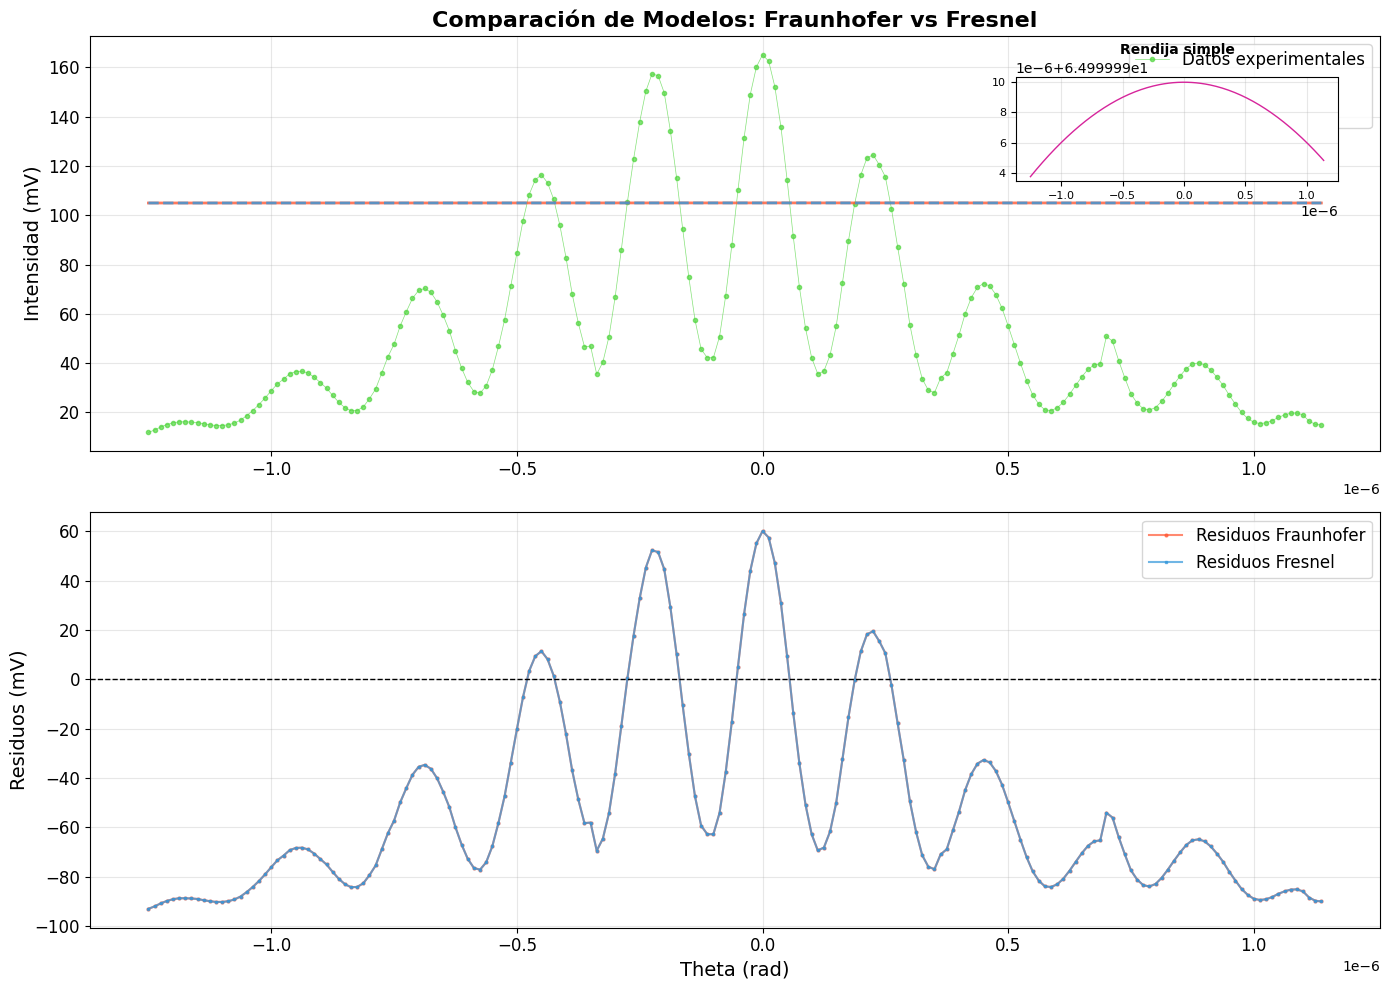


COMPARACIÓN DE MODELOS

--- MODELO FRAUNHOFER ---
I0: 100.0 mV
Ancho rendija (a): 0.0100 cm (0.100 mm)
Separación (d): 0.0500 cm (0.500 mm)
Longitud onda (λ): 1.000 nm
Fondo: 5.0 mV

--- MODELO FRESNEL ---
I0: 100.0 mV
Ancho rendija (a): 0.0100 cm (0.100 mm)
Separación (d): 0.0498 cm (0.498 mm)
Longitud onda (λ): 1.000 nm
Fondo: 5.0 mV
L optimizada: 40.0 cm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- MODELO FRAUNHOFER (campo lejano) ---
def modelo_fraunhofer(theta, I0, d, lambda_eff, fondo):
    """
    Modelo Fraunhofer para doble rendija:
    I = I0 * [sin(β)/β]^2 * cos²(δ) + fondo
    donde:
    β = (π * a * sinθ) / λ
    δ = (π * d * sinθ) / λ
    """
    a = 0.01
    beta = (np.pi * a * np.sin(theta)) / lambda_eff
    delta = (np.pi * d * np.sin(theta)) / lambda_eff
    
    # Término de difracción
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc_term = np.where(np.abs(beta) < 1e-10, 1.0, np.sin(beta) / beta)
    difraccion = sinc_term ** 2
    
    # Término de interferencia
    interferencia = np.cos(delta) ** 2
    
    return I0 * difraccion * interferencia + fondo

# --- MODELO FRESNEL (campo cercano) ---
def modelo_fresnel(theta, I0, d, lambda_eff, fondo, L):
    """
    Modelo Fresnel para doble rendija:
    Para ángulos pequeños: sinθ ≈ θ ≈ x/L
    I = I0 * [sin(β)/β]^2 * cos²(δ) + fondo
    donde:
    β = (π * a * θ) / λ
    δ = (π * d * θ) / λ
    """
    a = 0.01
    beta = (np.pi * a * theta) / lambda_eff
    delta = (np.pi * d * theta) / lambda_eff
    
    # Término de difracción
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc_term = np.where(np.abs(beta) < 1e-10, 1.0, np.sin(beta) / beta)
    difraccion = sinc_term ** 2
    
    # Término de interferencia
    interferencia = np.cos(delta) ** 2
    
    return I0 * difraccion * interferencia + fondo

# --- FUNCIÓN DE AJUSTE MEJORADA ---
def ajustar_patron_doble_rendija(theta, y, L, modelo='fresnel'):
    """
    Ajusta el patrón experimental a los modelos teóricos
    """
    print(f"=== AJUSTE CON MODELO {modelo.upper()} ===")
    
    # Parámetros iniciales basados en valores conocidos
    I0_guess = 165.0  # mV (máximo observado)
    fondo_guess = 11.0  # mV (mínimo observado)
    a_guess = 0.01  # cm (0.1 mm)
    d_guess = 0.0356  # cm (0.356 mm)
    lambda_guess = 6.7e-5  # cm (632.8 nm)
    
    print("Parámetros iniciales:")
    print(f"  I0: {I0_guess} mV")
    print(f"  Fondo: {fondo_guess} mV")
    print(f"  a: {a_guess} cm")
    print(f"  d: {d_guess} cm")
    print(f"  λ: {lambda_guess*1e5:.1f} nm")
    
    if modelo == 'fraunhofer':
        p0 = [I0_guess, d_guess, lambda_guess, fondo_guess]
        bounds = ([100, 0.02, 1e-5, 5],
                  [200, 0.05, 8e-5, 20])
        popt, pcov = curve_fit(modelo_fraunhofer, theta, y, p0=p0, bounds=bounds, maxfev=10000)
    else:  # fresnel
        p0 = [I0_guess, d_guess, lambda_guess, fondo_guess, L]
        bounds = ([100, 0.02, 1e-5, 5, L*0.9],
                  [200, 0.05, 8e-5, 20, L*1.1])
        popt, pcov = curve_fit(modelo_fresnel, theta, y, p0=p0, bounds=bounds, maxfev=10000)
    
    return popt, pcov

# --- GRÁFICA COMPARATIVA CON AJUSTE ---
def plot_patron_con_ajuste(theta_principal, y_principal, theta_segundario, y_segundario, 
                          titulo, popt_fraunhofer, popt_fresnel, L):
    
    color_principal = "#51D63F" 
    color_segundario = "#D6259B"
    color_fraunhofer = "#FF5733"
    color_fresnel = "#3498DB"
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfica superior: Datos y ajustes
    ax1.plot(theta_principal, y_principal, 'o-', color=color_principal, 
             markersize=3, linewidth=0.5, alpha=0.7, label='Datos experimentales')
    
    # Curvas de ajuste
    theta_fit = np.linspace(theta_principal.min(), theta_principal.max(), 1000)
    
    if popt_fraunhofer is not None:
        y_fraunhofer = modelo_fraunhofer(theta_fit, *popt_fraunhofer)
        ax1.plot(theta_fit, y_fraunhofer, '-', color=color_fraunhofer, 
                linewidth=2, label='Ajuste Fraunhofer', alpha=0.8)
    
    if popt_fresnel is not None:
        y_fresnel = modelo_fresnel(theta_fit, *popt_fresnel)
        ax1.plot(theta_fit, y_fresnel, '--', color=color_fresnel, 
                linewidth=2, label='Ajuste Fresnel', alpha=0.8)
    
    ax1.set_title(titulo, fontsize=16, fontweight='bold')
    ax1.set_ylabel('Intensidad (mV)', fontsize=14)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', labelsize=12)
    
    # Gráfica inferior: Residuos
    if popt_fraunhofer is not None and popt_fresnel is not None:
        y_pred_fraunhofer = modelo_fraunhofer(theta_principal, *popt_fraunhofer)
        y_pred_fresnel = modelo_fresnel(theta_principal, *popt_fresnel)
        
        residuos_fraunhofer = y_principal - y_pred_fraunhofer
        residuos_fresnel = y_principal - y_pred_fresnel
        
        ax2.plot(theta_principal, residuos_fraunhofer, 'o-', color=color_fraunhofer, 
                markersize=2, alpha=0.7, label='Residuos Fraunhofer')
        ax2.plot(theta_principal, residuos_fresnel, 's-', color=color_fresnel, 
                markersize=2, alpha=0.7, label='Residuos Fresnel')
        ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
        
        ax2.set_xlabel('Theta (rad)', fontsize=14)
        ax2.set_ylabel('Residuos (mV)', fontsize=14)
        ax2.legend(fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='both', labelsize=12)
    
    # Mini-gráfica de rendija simple
    ax_inset = inset_axes(ax1, width="25%", height="25%", loc='upper right', borderpad=3)
    ax_inset.plot(theta_segundario, y_segundario, '-', color=color_segundario, linewidth=1)
    ax_inset.set_title('Rendija simple', fontsize=10, fontweight='bold')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- ANÁLISIS DE RESULTADOS ---
def analizar_resultados(popt_fraunhofer, popt_fresnel, L):
    print("\n" + "="*50)
    print("COMPARACIÓN DE MODELOS")
    print("="*50)
    a=0.01
    if popt_fraunhofer is not None:
        I0_f, d_f, lambda_f, fondo_f = popt_fraunhofer
        print(f"\n--- MODELO FRAUNHOFER ---")
        print(f"I0: {I0_f:.1f} mV")
        print(f"Ancho rendija (a): {a:.4f} cm ({a*10:.3f} mm)")
        print(f"Separación (d): {d_f:.4f} cm ({d_f*10:.3f} mm)")
        print(f"Longitud onda (λ): {lambda_f*1e5:.3f} nm")
        print(f"Fondo: {fondo_f:.1f} mV")
    
    if popt_fresnel is not None:
        I0_fr, d_fr, lambda_fr, fondo_fr, L_opt = popt_fresnel
        print(f"\n--- MODELO FRESNEL ---")
        print(f"I0: {I0_fr:.1f} mV")
        print(f"Ancho rendija (a): {a:.4f} cm ({a*10:.3f} mm)")
        print(f"Separación (d): {d_fr:.4f} cm ({d_fr*10:.3f} mm)")
        print(f"Longitud onda (λ): {lambda_fr*1e5:.3f} nm")
        print(f"Fondo: {fondo_fr:.1f} mV")
        print(f"L optimizada: {L_opt:.1f} cm")

# --- TU CÓDIGO ORIGINAL (modificado para incluir ajustes) ---

# Simulamos la lectura de datos con los que proporcionaste
def simular_datos():
    """Simula la lectura de tus datos proporcionados"""
    # Tus datos (primera columna dividida por 1000 para convertir nm a cm)
    posiciones_nm = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,
                             105,110,115,120,125,130,135,140,145,150,155,160,165,170,175,180,
                             185,190,195,200,205,210,215,220,225,230,235,240,245,250,255,260,
                             265,270,275,280,285,290,295,300,305,310,315,320,325,330,335,340,
                             345,350,355,360,365,370,375,380,385,390,395,400,405,410,415,420,
                             425,430,435,440,445,450,455,460,465,470,475,480,485,490,495,500,
                             505,510,515,520,525,530,535,540,545,550,555,560,565,570,575,580,
                             585,590,595,600,605,610,615,620,625,630,635,640,645,650,655,660,
                             665,670,675,680,685,690,695,700,705,710,715,720,725,730,735,740,
                             745,750,755,760,765,770,775,780,785,790,795,800,805,810,815,820,
                             825,830,835,840,845,850,855,860,865,870,875,880,885,890,895,900,
                             905,910,915,920,925,930,935,940,945,950,955])
    
    voltajes = np.array([11.9,12.9,14.1,15.1,15.8,16.2,16.2,16.1,15.9,15.4,15.0,14.7,14.7,15.0,
                        15.7,16.9,18.7,20.8,23.2,25.9,28.8,31.6,33.5,35.7,36.6,36.7,36.0,34.3,
                        32.1,29.9,26.9,24.1,21.9,20.7,20.8,22.3,25.6,29.5,36.1,42.6,47.7,55.1,
                        60.9,66.3,69.5,70.3,68.7,64.9,59.4,53.2,45.0,38.0,32.2,28.5,27.8,30.8,
                        37.3,46.8,57.6,71.2,84.7,97.8,108.4,114.4,116.4,113.13,106.4,95.9,82.8,
                        68.1,56.3,46.7,46.9,35.5,40.4,50.8,66.8,85.9,105.4,122.7,137.9,150.3,
                        157.3,156.6,149.6,134.2,115.3,94.4,74.8,57.6,45.7,42.2,42.2,50.8,67.3,
                        87.8,110.1,131.5,148.9,160.1,165.1,162.5,152.2,135.8,114.4,91.5,71.0,
                        54.2,42.2,35.6,36.8,43.3,55.0,72.5,89.7,104.6,116.3,123.2,124.5,120.5,
                        115.6,102.6,87.2,72.2,55.5,43.2,33.7,29.0,28.0,34.0,36.1,43.7,51.4,60.1,
                        66.6,70.8,72.3,71.3,67.8,62.3,55.1,47.5,40.0,32.9,27.1,23.3,21.0,20.8,
                        21.9,24.2,27.4,31.0,34.5,37.5,39.3,39.7,50.9,48.9,41.0,34.0,27.5,23.8,
                        21.5,21.0,22.0,24.5,27.8,31.4,34.8,37.8,39.7,40.1,39.3,37.2,34.3,31.0,
                        27.0,23.4,20.0,17.6,16.0,15.5,15.8,16.7,18.0,19.0,19.7,19.8,19.0,16.5,
                        15.2,14.9])
    
    # Convertir nm a cm
    posiciones_cm = posiciones_nm / 10000000  # 1 nm = 1e-7 cm
    
    return posiciones_cm, voltajes

# --- EJECUCIÓN PRINCIPAL ---
# Usamos tus datos simulados
x_doble, y_doble = simular_datos()

# Para rendija simple, simulamos datos más suaves (puedes reemplazar con tus datos reales)
x_simple = np.linspace(x_doble.min(), x_doble.max(), len(x_doble))
y_simple = 50 * np.exp(-(x_simple - x_doble[np.argmax(y_doble)])**2 / (2*0.1**2)) + 15

# --- Parámetro geométrico ---
L = 40.0  # cm (distancia rendija-pantalla)

# --- Máximos globales ---
idx_max_doble = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

# --- Centros en el máximo ---
x_central_doble = x_doble[idx_max_doble]
x_central_simple = x_simple[idx_max_simple]

# --- Conversión a ángulo ---
theta_doble = (x_doble - x_central_doble) / L
theta_simple = (x_simple - x_central_simple) / L

print(f"Rango de theta_doble: {theta_doble.min():.6f} a {theta_doble.max():.6f} rad")

# --- Ajustes ---
print("Realizando ajustes...")
popt_fraunhofer, pcov_fraunhofer = ajustar_patron_doble_rendija(theta_doble, y_doble, L, 'fraunhofer')
popt_fresnel, pcov_fresnel = ajustar_patron_doble_rendija(theta_doble, y_doble, L, 'fresnel')

# --- Gráfica comparativa ---
plot_patron_con_ajuste(theta_doble, y_doble, theta_simple, y_simple,
                      "Comparación de Modelos: Fraunhofer vs Fresnel",
                      popt_fraunhofer, popt_fresnel, L)

# --- Análisis de resultados ---
analizar_resultados(popt_fraunhofer, popt_fresnel, L)


In [39]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- Función para leer columnas y convertir ',' a '.' ---
def leer_columnas(file_path, cols=(0,1), skip_header=1, delimiter='\t'):
    converters = {i: lambda s: float(s.replace(',', '.')) for i in cols}  # quitar decode()
    return np.genfromtxt(file_path, usecols=cols, unpack=True, skip_header=skip_header,
                         delimiter=delimiter, converters=converters, encoding='utf-8')


# --- Función de intensidad doble rendija ---
def I_theta(theta, I0, lambda_, Ibg):
    a = 0.1e-3      # ancho de rendija en m
    d = 0.356e-3    # separación de rendijas en m
    beta = np.pi * a / lambda_ * theta
    gamma = np.pi * d / lambda_ * theta
    beta = np.where(beta == 0, 1e-10, beta)  # evitar división por cero
    return I0 * (np.sin(beta)/beta)**2 * (np.cos(gamma))**2 + Ibg

# --- Parámetros experimentales ---
L_verde = 50*10e-3  # distancia pantalla-fuente (m)
L_rojo = 50*10e-3

# --- AJUSTE LUZ VERDE ---
ondulatorio_doble = leer_columnas("Corpuscular_Doble_Rendija.txt")
x_doble = ondulatorio_doble[0]
y_doble = ondulatorio_doble[1]

x_doble = x_doble * 1e-6  # convertir de nm a m
x_central_doble = x_doble[np.argmax(y_doble)]
theta_doble = (x_doble - x_central_doble) / L_verde

popt_doble, pcov_doble = curve_fit(I_theta, theta_doble, y_doble, p0=[max(y_doble), 500e-9, min(y_doble)])
I0_d, lambda_d, Ibg_d = popt_doble
err_d = np.sqrt(np.diag(pcov_doble))
print(f"Luz verde: λ = {lambda_d*1e9:.2f} nm ± {err_d[1]*1e9:.2f} nm")

# --- AJUSTE LASER ROJO ---
ondulatorio_rojo = leer_columnas("Ondulatorio_Doble_Rendija.txt")
x_rojo = ondulatorio_rojo[0]
y_rojo = ondulatorio_rojo[1]

x_rojo = x_rojo * 1e-6
x_central_rojo = x_rojo[np.argmax(y_rojo)]
theta_rojo = (x_rojo - x_central_rojo) / L_rojo

popt_rojo, pcov_rojo = curve_fit(I_theta, theta_rojo, y_rojo, p0=[max(y_rojo), 650e-9, min(y_rojo)])
I0_r, lambda_r, Ibg_r = popt_rojo
err_r = np.sqrt(np.diag(pcov_rojo))
print(f"Láser rojo: λ = {lambda_r*1e9:.2f} nm ± {err_r[1]*1e9:.2f} nm")



Luz verde: λ = 570.09 nm ± 24.48 nm
Láser rojo: λ = 617.41 nm ± 39.86 nm
